# The Cross Resonance (CR) Gate

> 💡 **What you need.** The simulation (sections 1–5) needs only QuTiP, NumPy and matplotlib and runs in a few seconds. The physical design (section 6) opens the desktop `MetalGUI`; see the callout below for running it without Qt.

> 💡 **Using this tutorial without the Qt GUI**
> 
> This tutorial uses the desktop `MetalGUI`. To follow along on Colab, Binder, JupyterHub, or any environment where Qt isn't available, **replace any `gui.rebuild()` / `gui.screenshot()` call with `qm.view(design)`** — it renders the design to a matplotlib `Figure` you can display inline or save with `fig.savefig(...)`.
> 
> See [1.1 Quick start](https://qiskit-community.github.io/qiskit-metal/tut/1-Overview/1.1-Quick-start.html) for a complete runnable walkthrough and [`docs/headless-usage.rst`](https://qiskit-community.github.io/qiskit-metal/headless-usage.html) for the full reference.

Here's what we'll work through in this tutorial notebook:

* what the cross-resonance (CR) gate is, and why it is conditional;
* a model of two coupled transmons (three levels each) with the control driven at the *dressed* frequency of the target;
* the time evolution of the target qubit for the control in $|0\rangle$ and in $|1\rangle$: the target rotates at two different rates;
* the effective $ZX$, $IX$ and $ZI$ rates, extracted numerically and compared with the standard perturbative formulas;
* a physical layout of the two qubits and their bus in Qiskit Metal.

## 1. What is the CR gate?

The cross-resonance gate couples two fixed-frequency qubits with microwaves alone. The two transmons are coupled, here through a bus resonator. One of them, the *control*, is driven at the transition frequency of the other, the *target*. The drive is off-resonant for the control, but through the coupling a small part of it reaches the target and makes it Rabi-oscillate.

The point of the gate is that the size of that leaked drive depends on the state of the control. The control's $|0\rangle\to|1\rangle$ and $|1\rangle\to|2\rangle$ transitions both hybridise with the target, by different amounts. So the target rotates about $X$ at one rate when the control is in $|0\rangle$ and at another when it is in $|1\rangle$. The difference is a $Z\otimes X$ ("$ZX$") interaction, and a $ZX$ rotation by $\pi/2$ is equivalent to a CNOT up to single-qubit gates.

## 2. The model

We use the Hamiltonian of two Duffing oscillators (transmons) with an exchange coupling $J$, and a drive on the control (qubit 1):

$$\frac{H}{\hbar} = \sum_{k=1,2}\Big[\omega_k\, b_k^\dagger b_k + \frac{\alpha_k}{2}\, b_k^\dagger b_k^\dagger b_k b_k\Big] + J\big(b_1^\dagger b_2 + b_1 b_2^\dagger\big) + \Omega\cos(\omega_d t)\,\big(b_1 + b_1^\dagger\big).$$

A few choices are worth spelling out.

* **Three levels per transmon.** The control's second excited state is not a detail. It sets both the size of $ZX$ and the size of the unwanted $IX$ term (section 4). Two-level qubits would give a different answer.
* **A direct $J$ instead of the bus.** The bus in section 6 is a $\lambda/2$ resonator about 0.75 GHz above the qubits, coupled to each with $g \approx 45$ MHz. Since $g \ll |\omega_k - \omega_r|$, the bus stays in its ground state, and eliminating it gives an exchange coupling between the qubits [6]
  $$J = \frac{g_1 g_2}{2}\Big(\frac{1}{\omega_1-\omega_r} + \frac{1}{\omega_2-\omega_r}\Big).$$
  We check in section 5 that keeping the bus explicitly gives the same rates.
* **The rotating frame.** In a frame rotating at the drive frequency $\omega_d$ for both transmons, and dropping terms that oscillate at $2\omega_d$ (the rotating-wave approximation), the Hamiltonian becomes time independent:
  $$\frac{\tilde H}{\hbar} = \sum_k\Big[(\omega_k-\omega_d)\, b_k^\dagger b_k + \frac{\alpha_k}{2}\, b_k^\dagger b_k^\dagger b_k b_k\Big] + J\big(b_1^\dagger b_2 + b_1 b_2^\dagger\big) + \frac{\Omega}{2}\big(b_1 + b_1^\dagger\big).$$
  All the Bloch vectors below are in this frame.

The numbers are representative of fixed-frequency transmons; tutorials 4.0x and 4.1x show how to get them for a real layout. Frequencies are in GHz and times in ns, so we multiply by $2\pi$ when building Hamiltonians.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

TWO_PI = 2 * np.pi

N = 3  # levels kept per transmon
w1, w2 = 4.90, 5.00  # control and target frequencies (GHz)
alpha1, alpha2 = -0.33, -0.33  # anharmonicities (GHz)
Delta = w1 - w2  # control-target detuning (GHz)

# The bus of section 6: a 10.5 mm half-wave CPW on silicon.
eps_eff = (11.45 + 1) / 2  # quasi-static effective permittivity of a CPW on Si
wr = 299792458 / (2 * 10.5e-3 * np.sqrt(eps_eff)) / 1e9  # bus frequency (GHz)
g = 0.045  # qubit-bus coupling (GHz), the same for both qubits
J = g * g / 2 * (1 / (w1 - wr) + 1 / (w2 - wr))  # bus-mediated exchange (GHz)

print(f"bus frequency     w_r/2pi = {wr:.2f} GHz")
print(f"exchange coupling   J/2pi = {J * 1e3:.2f} MHz")
print(f"detuning        Delta/2pi = {Delta * 1e3:.0f} MHz  (J/Delta = {J / Delta:.3f})")

bus frequency     w_r/2pi = 5.72 GHz
exchange coupling   J/2pi = -2.63 MHz
detuning        Delta/2pi = -100 MHz  (J/Delta = 0.026)


### Operators and the dressed frequencies

The coupling shifts the levels slightly, so the target's transition frequency is not $\omega_2$ any more. We find the *dressed* states by diagonalising the undriven Hamiltonian and labelling each eigenstate by the bare state it overlaps most. The drive goes at the dressed target frequency with the control in $|0\rangle$, $\tilde\omega_2 = E_{\widetilde{01}} - E_{\widetilde{00}}$. The same diagonalisation gives the static $ZZ$ shift $\zeta = E_{\widetilde{11}} - E_{\widetilde{10}} - E_{\widetilde{01}} + E_{\widetilde{00}}$, which we compare with the perturbative $\zeta = 2J^2(\alpha_1+\alpha_2)/[(\Delta+\alpha_1)(\Delta-\alpha_2)]$.

In [2]:
b1 = qt.tensor(qt.destroy(N), qt.qeye(N))  # control
b2 = qt.tensor(qt.qeye(N), qt.destroy(N))  # target


def H_undriven(wd):
    # Undriven Hamiltonian (rad/ns) in the frame rotating at wd (GHz).
    H = J * (b1.dag() * b2 + b1 * b2.dag())
    for b, w, a in ((b1, w1, alpha1), (b2, w2, alpha2)):
        H += (w - wd) * b.dag() * b + a / 2 * b.dag() * b.dag() * b * b
    return TWO_PI * H


def ket(i, j):
    return qt.tensor(qt.basis(N, i), qt.basis(N, j))


COMPUTATIONAL = [ket(0, 0), ket(0, 1), ket(1, 0), ket(1, 1)]


def dressed(H, bare_kets):
    # Eigenvalues (GHz) and eigenvectors (columns) that overlap most with each bare ket.
    E, V = np.linalg.eigh(H.full())
    energies, vectors = [], []
    for k in bare_kets:
        overlap = k.full().ravel().conj() @ V
        i = np.argmax(np.abs(overlap))
        energies.append(E[i] / TWO_PI)
        vectors.append(V[:, i] * np.exp(-1j * np.angle(overlap[i])))  # fix the phase
    return np.array(energies), np.array(vectors).T


(E00, E01, E10, E11), _ = dressed(H_undriven(0), COMPUTATIONAL)
wd = E01 - E00  # dressed target frequency, control in |0>
zeta = E11 - E10 - E01 + E00
zeta_formula = 2 * J**2 * (alpha1 + alpha2) / ((Delta + alpha1) * (Delta - alpha2))

print(f"dressed target frequency = {wd:.6f} GHz  (bare {w2:.6f} GHz)")
print(
    f"static ZZ  zeta/2pi = {zeta * 1e6:.1f} kHz   (formula {zeta_formula * 1e6:.1f} kHz)"
)

dressed target frequency = 5.000069 GHz  (bare 5.000000 GHz)
static ZZ  zeta/2pi = 92.6 kHz   (formula 92.7 kHz)


The shift of the target is only $\approx J^2/\Delta$, tens of kHz here, small compared with the CR rates below, but driving at the bare frequency would add a slow $Z$ rotation to the target. The static $ZZ$ is the always-on conditional phase that every fixed-coupling architecture lives with.

## 3. Driving the control at the target frequency

Now we turn on the drive, $\Omega/2\pi = 40$ MHz at $\omega_d = \tilde\omega_2$, and evolve the target from $|0\rangle$ twice: once with the control in $|0\rangle$ and once with the control in $|1\rangle$. We record the three Bloch components of the target, $\langle X\rangle$, $\langle Y\rangle$, $\langle Z\rangle$, using Pauli operators on its two lowest levels.

largest difference in target |1> population between the two control states: 0.90


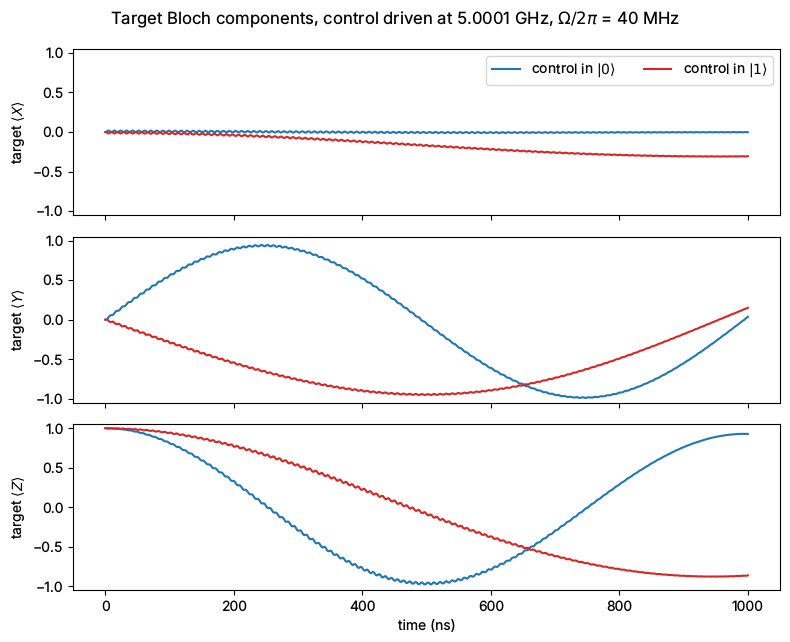

In [3]:
Omega = 0.040  # drive amplitude (GHz)
H_drive = TWO_PI * Omega / 2 * (b1 + b1.dag())
H = H_undriven(wd) + H_drive


def on_target(op2):
    # A 2x2 operator on the target's two lowest levels, identity on the control.
    op = np.zeros((N, N), complex)
    op[:2, :2] = op2
    return qt.tensor(qt.qeye(N), qt.Qobj(op))


sx = on_target([[0, 1], [1, 0]])
sy = on_target([[0, -1j], [1j, 0]])
sz = on_target([[1, 0], [0, -1]])

tlist = np.linspace(0, 1000, 1001)  # ns
bloch = {}
for c in (0, 1):
    result = qt.sesolve(H, ket(c, 0), tlist, e_ops=[sx, sy, sz])
    bloch[c] = np.array(result.expect).real

fig, axes = plt.subplots(3, 1, figsize=(8, 6.5), sharex=True)
for ax, k, name in zip(axes, range(3), ("X", "Y", "Z")):
    for c, color in ((0, "C0"), (1, "C3")):
        ax.plot(tlist, bloch[c][k], color=color, label=f"control in $|{c}\\rangle$")
    ax.set_ylabel(f"target $\\langle {name}\\rangle$")
    ax.set_ylim(-1.05, 1.05)
axes[0].legend(loc="upper right", ncol=2)
axes[-1].set_xlabel("time (ns)")
fig.suptitle(
    f"Target Bloch components, control driven at {wd:.4f} GHz, $\\Omega/2\\pi$ = {Omega * 1e3:.0f} MHz"
)
fig.tight_layout()

P1_diff = np.max(np.abs(bloch[0][2] - bloch[1][2])) / 2
print(
    f"largest difference in target |1> population between the two control states: {P1_diff:.2f}"
)

The conditionality is plain to see. With the control in $|0\rangle$ the target rotates about $X$ quickly, with the control in $|1\rangle$ slowly and in the opposite sense (compare the signs of $\langle Y\rangle$). With the control in $|0\rangle$, $\langle X\rangle$ stays at zero: the drive is exactly on resonance and acts along $X$. With the control in $|1\rangle$ the target is detuned by the static $ZZ$ shift $\zeta$, so its rotation axis tilts slightly out of the $YZ$ plane and $\langle X\rangle$ drifts away from zero. The small fast ripple is the off-resonant drive on the control.

## 4. The effective Hamiltonian

Restricted to the computational states, and with the control's off-resonant dynamics averaged out, the driven system behaves as

$$\frac{H_\mathrm{eff}}{\hbar} = \frac{\omega_{ZX}}{2}\, Z\otimes X + \frac{\omega_{IX}}{2}\, I\otimes X + \frac{\omega_{ZI}}{2}\, Z\otimes I + \dots,$$

so the target rotates at $\omega_{IX}+\omega_{ZX}$ when the control is in $|0\rangle$ and at $\omega_{IX}-\omega_{ZX}$ when it is in $|1\rangle$. $\omega_{ZI}$ is the Stark shift of the control by its own drive.

**Where the rates come from.** To first order in $J$, the dressed states mix the control's excitation into the target's: $|\widetilde{01}\rangle \approx |01\rangle - \frac{J}{\Delta}|10\rangle$, and $|\widetilde{11}\rangle$ picks up $|20\rangle$ through the control's $1\to2$ transition. The drive operator $b_1$ therefore flips the target with amplitude $-J/\Delta$ when the control is in $|0\rangle$, and $J/\Delta - 2J/(\Delta+\alpha_1)$ when it is in $|1\rangle$. Half the sum and half the difference, times the drive $\Omega/2$, give the leading-order rates derived by Magesan and Gambetta [5] (see also Tripathi *et al.* [4]), here in the conventions of this notebook:

$$\omega_{ZX} = -\frac{J\Omega}{\Delta}\,\frac{\alpha_1}{\Delta+\alpha_1}, \qquad
\omega_{IX} = -\frac{J\Omega}{\Delta+\alpha_1}, \qquad
\omega_{ZI} = -\frac{\Omega^2}{2}\,\frac{\alpha_1}{\Delta(\Delta+\alpha_1)}.$$

Two consequences: both $ZX$ and $IX$ scale with $J\Omega$, and $IX$ vanishes only for a two-level control ($\alpha_1\to\infty$). For a transmon it is always there, which is why practical CR gates use an echo or a cancellation tone on the target [3].

**Numerically, without perturbation theory.** $\tilde H$ is time independent, so we can diagonalise it exactly and *block-diagonalise* it with respect to the control: the two eigenstates closest to $\{|\widetilde{00}\rangle,|\widetilde{01}\rangle\}$ form one block, those closest to $\{|\widetilde{10}\rangle,|\widetilde{11}\rangle\}$ the other. The rotation that maps each block back onto its dressed states with the least change (the unitary part of the overlap matrix) gives $H_\mathrm{eff}$ exactly, and its Pauli components are the rates.

In [4]:
PAULIS = {
    "I": np.eye(2),
    "X": np.array([[0, 1], [1, 0]]),
    "Y": np.array([[0, -1j], [1j, 0]]),
    "Z": np.diag([1.0, -1.0]),
}


def cr_rates(H, H0, comp_kets):
    # Pauli rates (GHz) of the effective Hamiltonian of H, block-diagonal in the control.
    # H0: the same system undriven, which defines the dressed computational states.
    # comp_kets: bare kets of |00>, |01>, |10>, |11> (control first).
    _, P = dressed(H0, comp_kets)
    E, V = np.linalg.eigh(H.full())
    H_eff = np.zeros((4, 4), complex)
    for block in (slice(0, 2), slice(2, 4)):
        Pb = P[:, block]
        idx = np.argsort(np.sum(np.abs(Pb.conj().T @ V) ** 2, axis=0))[-2:]
        U, _, Wh = np.linalg.svd(Pb.conj().T @ V[:, idx])
        R = U @ Wh  # unitary part of the overlap matrix
        H_eff[block, block] = R @ np.diag(E[idx]) @ R.conj().T
    return {
        a + b: np.trace(np.kron(PAULIS[a], PAULIS[b]) @ H_eff).real / 2 / TWO_PI
        for a in "IZ"
        for b in "IXYZ"
    }


def formulas(Om):
    return {
        "ZX": -J * Om / Delta * alpha1 / (Delta + alpha1),
        "IX": -J * Om / (Delta + alpha1),
        "ZI": -(Om**2) / 2 * alpha1 / (Delta * (Delta + alpha1)),
    }


H0 = H_undriven(wd)
rates0 = cr_rates(H0, H0, COMPUTATIONAL)
rates = cr_rates(H, H0, COMPUTATIONAL)
rates["ZI"] -= rates0["ZI"]  # keep only the drive-induced part of ZI
f = formulas(Omega)

print(f"Omega/2pi = {Omega * 1e3:.0f} MHz      numerical    formula   (MHz)")
for k in ("ZX", "IX", "ZI"):
    print(f"   omega_{k}/2pi        {rates[k] * 1e3:9.4f}  {f[k] * 1e3:9.4f}")
print(
    f"   largest Y term       |omega_ZY|, |omega_IY| < {max(abs(rates['ZY']), abs(rates['IY'])) * 1e3:.0e} MHz"
)
print(f"ZX(pi/2) gate time at this drive: {1 / (4 * abs(rates['ZX'])):.0f} ns")

Omega/2pi = 40 MHz      numerical    formula   (MHz)
   omega_ZX/2pi          -0.7611    -0.8088
   omega_IX/2pi          -0.2438    -0.2451
   omega_ZI/2pi           5.9466     6.1395
   largest Y term       |omega_ZY|, |omega_IY| < 6e-17 MHz
ZX(pi/2) gate time at this drive: 328 ns


The $Y$ terms vanish because the drive has a single, real phase and no classical crosstalk reaches the target directly. At this drive the numerical $ZX$ is already about 6 % below the first-order formula, while $IX$ still agrees. Sweeping the drive amplitude shows where the formulas hold:

ratio numerical / formula at Omega/2pi = 1 MHz: ZX 0.9987, IX 0.9996, ZI 0.9982


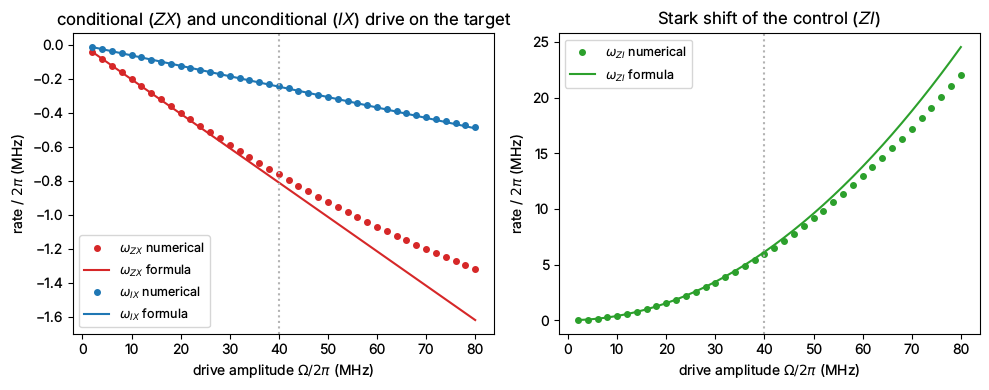

In [5]:
Omegas = np.linspace(0.002, 0.08, 40)
sweep = {k: [] for k in ("ZX", "IX", "ZI")}
for Om in Omegas:
    r = cr_rates(H0 + TWO_PI * Om / 2 * (b1 + b1.dag()), H0, COMPUTATIONAL)
    r["ZI"] -= rates0["ZI"]
    for k in sweep:
        sweep[k].append(r[k])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
for ax, keys in ((ax1, ("ZX", "IX")), (ax2, ("ZI",))):
    for k in keys:
        color = {"ZX": "C3", "IX": "C0", "ZI": "C2"}[k]
        ax.plot(
            Omegas * 1e3,
            np.array(sweep[k]) * 1e3,
            "o",
            ms=4,
            color=color,
            label=f"$\\omega_{{{k}}}$ numerical",
        )
        ax.plot(
            Omegas * 1e3,
            formulas(Omegas)[k] * 1e3,
            "-",
            color=color,
            label=f"$\\omega_{{{k}}}$ formula",
        )
    ax.axvline(Omega * 1e3, color="0.7", ls=":")
    ax.set_xlabel("drive amplitude $\\Omega/2\\pi$ (MHz)")
    ax.set_ylabel("rate / $2\\pi$ (MHz)")
    ax.legend(fontsize=9)
ax1.set_title("conditional ($ZX$) and unconditional ($IX$) drive on the target")
ax2.set_title("Stark shift of the control ($ZI$)")
fig.tight_layout()

slope = cr_rates(
    H0 + TWO_PI * 0.0005 * (b1 + b1.dag()), H0, COMPUTATIONAL
)  # Omega/2pi = 1 MHz
f1 = formulas(0.001)
print(
    "ratio numerical / formula at Omega/2pi = 1 MHz:",
    f"ZX {slope['ZX'] / f1['ZX']:.4f}, IX {slope['IX'] / f1['IX']:.4f}, "
    f"ZI {(slope['ZI'] - rates0['ZI']) / f1['ZI']:.4f}",
)

At weak drive the exact rates and the formulas agree to 0.2 % or better, the size of the $(J/\Delta)^2$ corrections the formulas leave out. As the drive grows, $\omega_{ZX}$ saturates below the linear law: the drive starts to populate the control's second excited state, which the leading-order theory treats only perturbatively [4, 5]. 

As a last check, the effective Hamiltonian should reproduce the time evolution of section 3, the way an experiment would test it: by measuring the target's Rabi frequency for each control state. For the control in $|0\rangle$ or $|1\rangle$, $H_\mathrm{eff}$ is a rotation of the target about $X$ at $\omega_{IX}\pm\omega_{ZX}$, plus a small $Z$ term $\omega_{IZ}\pm\omega_{ZZ}$: zero for the control in $|0\rangle$, where we tuned the drive, and the static $ZZ$ shift for the control in $|1\rangle$. So the target should oscillate at $\sqrt{(\omega_{IX}\pm\omega_{ZX})^2 + (\omega_{IZ}\pm\omega_{ZZ})^2}$. We fit a cosine to $\langle Z\rangle(t)$ of the full simulation:

In [6]:
from scipy.optimize import curve_fit


def cosine(t, A, f, phi, B):
    return A * np.cos(TWO_PI * f * t + phi) + B


for c, sign in ((0, +1), (1, -1)):
    f_x = rates["IX"] + sign * rates["ZX"]
    f_z = rates["IZ"] + sign * rates["ZZ"]
    f_heff = np.hypot(f_x, f_z)
    (_, f_fit, _, _), _ = curve_fit(cosine, tlist, bloch[c][2], p0=[1, f_heff, 0, 0])
    print(
        f"control in |{c}>:  H_eff {f_heff * 1e3:.4f} MHz,  fit to the simulation {abs(f_fit) * 1e3:.4f} MHz"
    )

control in |0>:  H_eff 1.0048 MHz,  fit to the simulation 1.0033 MHz
control in |1>:  H_eff 0.5249 MHz,  fit to the simulation 0.5250 MHz


The two agree to a fraction of a per cent; the small difference comes from the fast ripple, which $H_\mathrm{eff}$ averages out by construction.

## 5. Does eliminating the bus matter?

Finally, we put the bus back: three modes (the bus as a harmonic oscillator, three levels), each qubit coupled to it with $g$, and no direct qubit-qubit coupling. The computational states are now those with the bus in its ground state, and the dressed target frequency is recomputed for this model.

In [7]:
a = qt.tensor(qt.qeye(N), qt.qeye(N), qt.destroy(3))  # bus
c1 = qt.tensor(qt.destroy(N), qt.qeye(N), qt.qeye(3))  # control
c2 = qt.tensor(qt.qeye(N), qt.destroy(N), qt.qeye(3))  # target


def H_bus(wd):
    H = (wr - wd) * a.dag() * a
    for b, w, al in ((c1, w1, alpha1), (c2, w2, alpha2)):
        H += (w - wd) * b.dag() * b + al / 2 * b.dag() * b.dag() * b * b
        H += g * (b.dag() * a + b * a.dag())
    return TWO_PI * H


kets3 = [
    qt.tensor(qt.basis(N, i), qt.basis(N, j), qt.basis(3, 0))
    for i, j in ((0, 0), (0, 1), (1, 0), (1, 1))
]
(F00, F01, _, _), _ = dressed(H_bus(0), kets3)
H0_bus = H_bus(F01 - F00)
r_bus0 = cr_rates(H0_bus, H0_bus, kets3)
r_bus = cr_rates(H0_bus + TWO_PI * Omega / 2 * (c1 + c1.dag()), H0_bus, kets3)
r_bus["ZI"] -= r_bus0["ZI"]

print(f"Omega/2pi = {Omega * 1e3:.0f} MHz   with bus   direct J   (MHz)")
for k in ("ZX", "IX", "ZI"):
    print(
        f"   omega_{k}/2pi     {r_bus[k] * 1e3:8.4f}   {rates[k] * 1e3:8.4f}   ratio {r_bus[k] / rates[k]:.3f}"
    )
print(f"2 (w1 - wr) / (w1 + w2 - 2 wr) = {2 * (w1 - wr) / (w1 + w2 - 2 * wr):.3f}")

Omega/2pi = 40 MHz   with bus   direct J   (MHz)
   omega_ZX/2pi      -0.8053    -0.7611   ratio 1.058
   omega_IX/2pi      -0.2584    -0.2438   ratio 1.060
   omega_ZI/2pi       5.9429     5.9466   ratio 0.999
2 (w1 - wr) / (w1 + w2 - 2 wr) = 1.065


The Stark shift is unchanged, but with the bus $ZX$ and $IX$ both come out about 6 % larger. The difference is not in $J$, which sets the level shifts correctly, but in how the drive reaches the target. With a direct coupling, the target's dressed state contains $J/(\omega_2-\omega_1)$ of the control. With a bus, that admixture is $g^2/[(\omega_2-\omega_1)(\omega_2-\omega_r)]$, which differs from the direct-$J$ value by the factor $2(\omega_1-\omega_r)/(\omega_1+\omega_2-2\omega_r)$ printed above whenever the two qubits sit at different detunings from the bus. So the direct-$J$ model is enough to understand the gate, and its formulas give the rates to within a few per cent; a design study keeps the bus, with $g$ and $\omega_r$ taken from simulations of the layout below.

## 6. Physical design of the CR gate

The physical design of a CR gate consists simply of two qubits connected via a bus resonator. For a concrete example of what this design may look like, we can use the example in H. Park *et al.*, Proc. IEEE IEDM (2020) [7], which shows several designs for a CR gate. We'll construct one very similar to the first.

Let's open up the Qiskit Metal design GUI:

In [ ]:
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, open_docs

While one could construct a CR gate using any transmon qubit design, we'll use the generic transmon pocket to be consistent with the paper:

In [ ]:
from qiskit_metal.qlibrary.qubits.transmon_pocket_6 import TransmonPocket6

design = metal.designs.DesignPlanar()
gui = metal.MetalGUI(design)

In [ ]:
design.overwrite_enabled = True
design.chips.main

For each of the two transmon qubits, we'll include two capacitively coupled pads: `bus_01`, which the bus resonator will join, and `readout`, left free for a readout resonator. We'll put one qubit at (-1,0) and the other at (1,0), the second rotated by 90 degrees relative to the first.

In [ ]:
Q1 = TransmonPocket6(
    design,
    "Q1",
    options=dict(
        pos_x="-1mm",
        pos_y="0mm",
        pad_width="425 um",
        pocket_height="650um",
        connection_pads=dict(
            readout=dict(loc_W=1, loc_H=1, pad_width="100um", pad_gap="50um"),
            bus_01=dict(loc_W=1, loc_H=-1, pad_width="100um", pad_gap="50um"),
        ),
    ),
)

Q2 = TransmonPocket6(
    design,
    "Q2",
    options=dict(
        pos_x="1mm",
        pos_y="0mm",
        orientation=-90,
        pad_width="425 um",
        pocket_height="650um",
        connection_pads=dict(
            readout=dict(loc_W=-1, loc_H=1, pad_width="100um", pad_gap="50um"),
            bus_01=dict(loc_W=-1, loc_H=-1, pad_width="100um", pad_gap="50um"),
        ),
    ),
)


gui.rebuild()
gui.autoscale()

Here's a screenshot showing the two qubits:

In [ ]:
gui.screenshot()

Now we just have to connect these two transmon qubits with a CPW. We'll use `RouteMeander` to join the `bus_01` pad of the first qubit to the `bus_01` pad of the second. A series of left-hand and right-hand turns mimics the shape of the resonator in the paper, and `total_length="10.5mm"` makes it a half-wave resonator near 5.7 GHz, the bus frequency used in section 2:

In [ ]:
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander

from collections import OrderedDict

jogs_start = OrderedDict()
jogs_start[0] = ["R", "1200um"]
jogs_start[1] = ["R", "200um"]
jogs_start[2] = ["R", "700um"]
jogs_start[3] = ["L", "200um"]
jogs_start[4] = ["L", "700um"]
jogs_start[5] = ["R", "200um"]
jogs_start[6] = ["R", "750um"]
jogs_start[7] = ["L", "200um"]
jogs_start[8] = ["L", "1200um"]
jogs_start[9] = ["L", "1800um"]
jogs_start[10] = ["L", "2500um"]

bus_01 = RouteMeander(
    design,
    "Coupler",
    options=dict(
        hfss_wire_bonds=True,
        pin_inputs=Dict(
            start_pin=Dict(component="Q1", pin="bus_01"),
            end_pin=Dict(component="Q2", pin="bus_01"),
        ),
        lead=Dict(
            start_straight="100um",  #'125um',
            start_jogged_extension=jogs_start,
            end_straight="100um",  #  '225um'
        ),
        meander=Dict(asymmetry="0um"),  #'1305um'),
        fillet="99um",
        total_length="10.5mm",
    ),
)
gui.rebuild()

And here's a screenshot showing the meandering CPW connection:

In [ ]:
gui.rebuild()
gui.autoscale()
gui.screenshot()

## Summary

| | this notebook |
|---|---|
| model | two three-level transmons, exchange $J$ from a dispersive bus |
| drive | control at the dressed target frequency, in the rotating frame |
| what makes it a gate | the target's Rabi rate depends on the control state: $\omega_{IX}\pm\omega_{ZX}$ |
| check of the rates | exact block-diagonalisation vs leading-order formulas [5]: within 0.2 % at $\Omega/2\pi$ = 1 MHz; at 40 MHz $IX$ within 1 %, $ZX$ 6 % below the linear law |
| check of the bus elimination | explicit bus vs direct $J$: same $ZI$; $ZX$ and $IX$ 6 % larger with the bus |
| layout | two `TransmonPocket6` qubits, `bus_01` pads joined by a 10.5 mm `RouteMeander` |

## Where to go next

* Add the echo: split the pulse in two halves with opposite sign and a $\pi$ pulse on the control in between [3]. $IX$ and $ZI$ cancel, $ZX$ stays.
* Move the control into the *straddling regime* $0 < \Delta < -\alpha_1$ (for example `w1 = 5.15`): $\omega_{ZX}$ grows and takes the opposite sign to $\omega_{IX}$. Near $\Delta = -\alpha_1$ the formulas diverge; compare them with the numerical rates there.
* Replace the guessed $g$ and $\omega_r$ by values from a simulation of the layout (tutorials 4.01–4.13), and the transmon parameters by those of tutorial 4.33.

## References

1. C. Rigetti and M. Devoret, Phys. Rev. B **81**, 134507 (2010), [doi:10.1103/PhysRevB.81.134507](https://doi.org/10.1103/PhysRevB.81.134507).
2. J. M. Chow *et al.*, Phys. Rev. Lett. **107**, 080502 (2011), [doi:10.1103/PhysRevLett.107.080502](https://doi.org/10.1103/PhysRevLett.107.080502).
3. S. Sheldon *et al.*, Phys. Rev. A **93**, 060302(R) (2016), [doi:10.1103/PhysRevA.93.060302](https://doi.org/10.1103/PhysRevA.93.060302).
4. V. Tripathi *et al.*, Phys. Rev. A **100**, 012301 (2019), [doi:10.1103/PhysRevA.100.012301](https://doi.org/10.1103/PhysRevA.100.012301).
5. E. Magesan and J. M. Gambetta, Phys. Rev. A **101**, 052308 (2020), [doi:10.1103/PhysRevA.101.052308](https://doi.org/10.1103/PhysRevA.101.052308).
6. M. Malekakhlagh, E. Magesan and D. C. McKay, Phys. Rev. A **102**, 042605 (2020), [doi:10.1103/PhysRevA.102.042605](https://doi.org/10.1103/PhysRevA.102.042605).
7. H. Park *et al.*, Proc. IEEE IEDM (2020), [ieeexplore 9371955](https://ieeexplore.ieee.org/document/9371955).